4187 2392


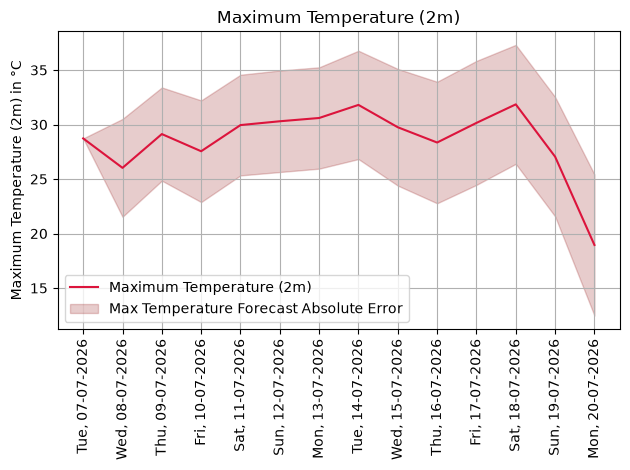

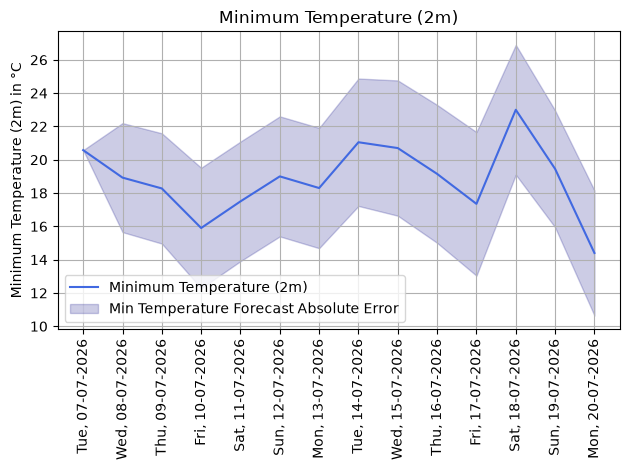

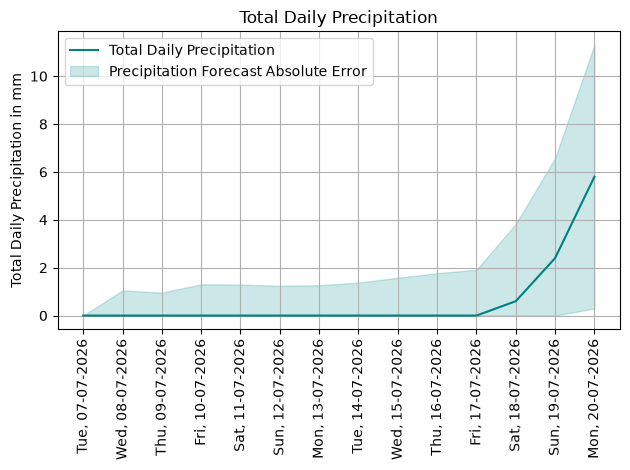

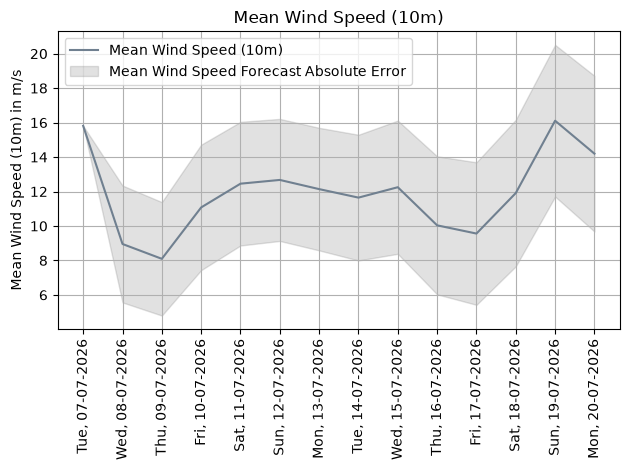

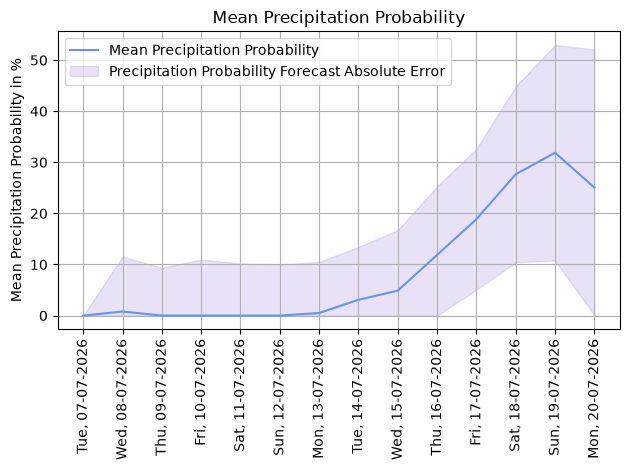

In [1]:
import pandas as pd

from fue import Config, Data, Forecast
from fue.models import MLUncertaintyModel, LinearUncertaintyModel

# ==========================================
# 1. Ingest and Pool Multi-City Datasets
# ==========================================
data = Data()
data.read_raw()
dataset = data.generate_dataset()
train_df, val_df = data.split_dataset(dataset, val_fraction=0.35, random_state=42, min_entries_per_city=100)

print(len(train_df), len(val_df))

# ==========================================
# 2. Instantiate Model and Configure Columns
# ==========================================

config = Config()
feature_columns = config.default_feature_columns
target_columns = config.default_target_columns 

# We use slightly stronger regularization (alpha=0.01) to protect the network weights
model = MLUncertaintyModel(hidden_layer_sizes=(16, 8), alpha=0.01, max_iter=2000)
model.fit(train_df, feature_columns, target_columns)

# ==========================================
# 3. Apply Model on Forecasts and Visualize
# ==========================================

F = Forecast()
F.fetch_forecast(location_name="aachen", forecast_days=14, past_days=0)
F.compute_uncertainties(model)
F.plot(target_variables=target_columns)

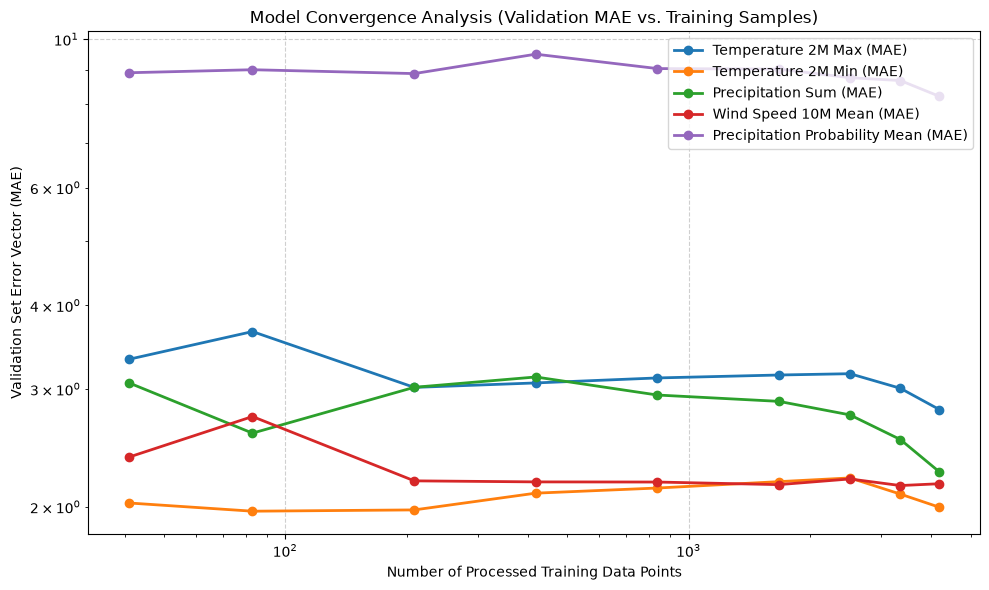

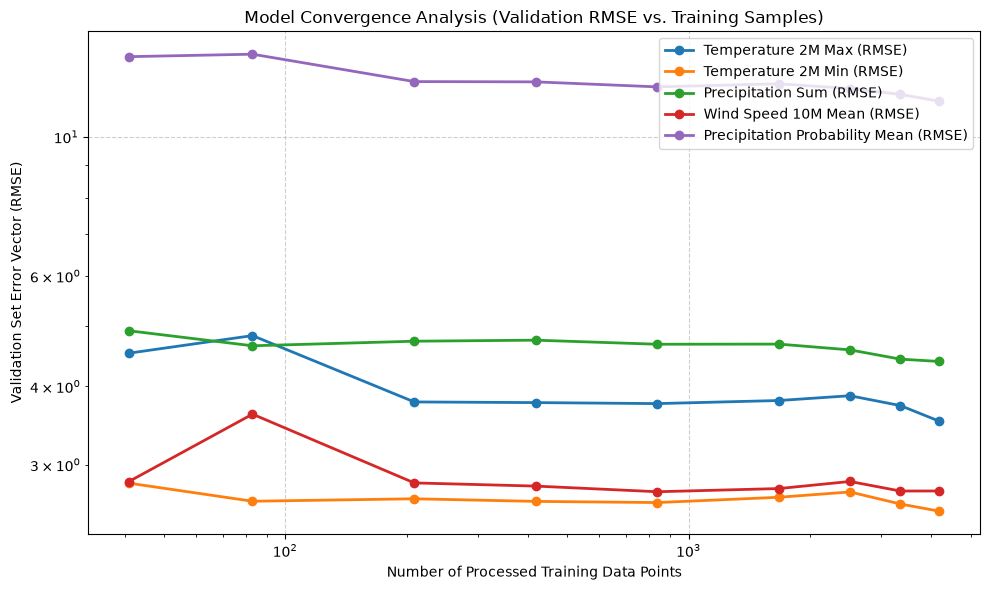


Final Multi-City Validation Set Error Metrics:
  abs_diff__temperature_2m_max: MAE=2.7937, RMSE=3.5177
  abs_diff__temperature_2m_min: MAE=1.9961, RMSE=2.5283
  abs_diff__precipitation_sum: MAE=2.2541, RMSE=4.3817
  abs_diff__wind_speed_10m_mean: MAE=2.1646, RMSE=2.7232
  abs_diff__precipitation_probability_mean: MAE=8.2135, RMSE=11.3931


In [2]:
# ==========================================
# 3. Run and Visually Plot Convergence Study
# ==========================================
# Compute errors across increasing data slices
convergence_results = model.study_data_convergence(train_df, val_df, feature_columns, target_columns)

# Trigger the newly implemented plotting capability
model.plot_learning_curve(convergence_results, metric="MAE")
model.plot_learning_curve(convergence_results, metric="RMSE")

# ==========================================
# 4. Final Evaluation Summary
# ==========================================
# Train the model statefully on the full 80% data pool
model.fit(train_df, feature_columns, target_columns)

# Get the final error metrics on the remaining 20% validation data
final_metrics = model.evaluate(val_df)

print("\nFinal Multi-City Validation Set Error Metrics:")
for target, metrics in final_metrics.items():
    print(f"  {target}: MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}")

In [3]:
data2 = Data()
data2.read_raw()
dataset = data2.generate_dataset()
print(len(dataset))

7209


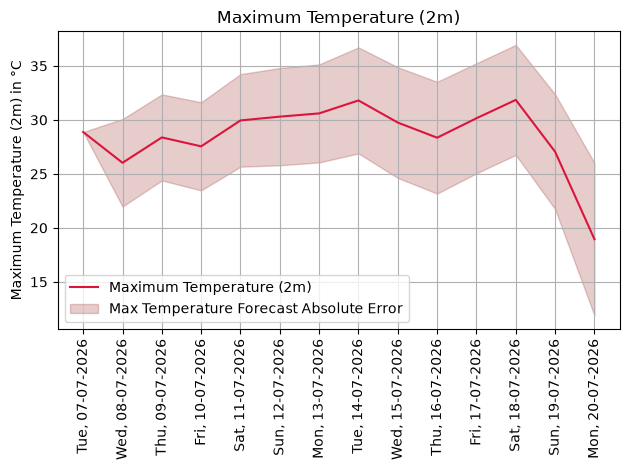

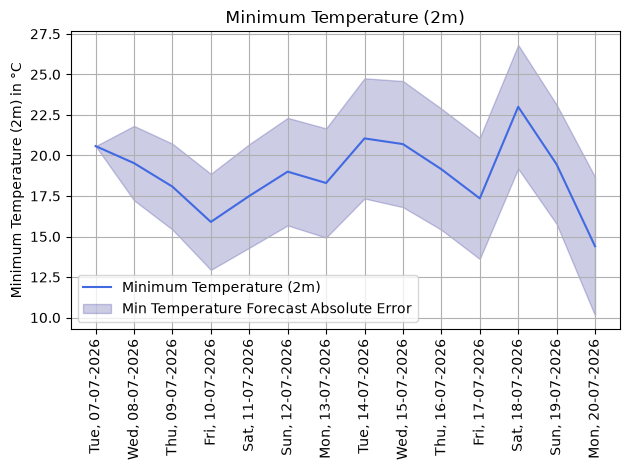

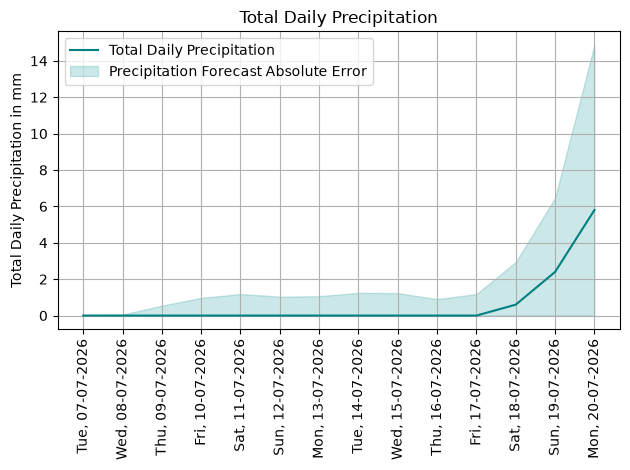

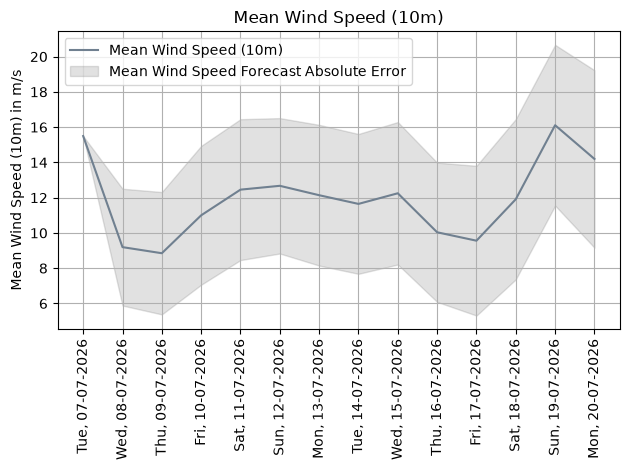

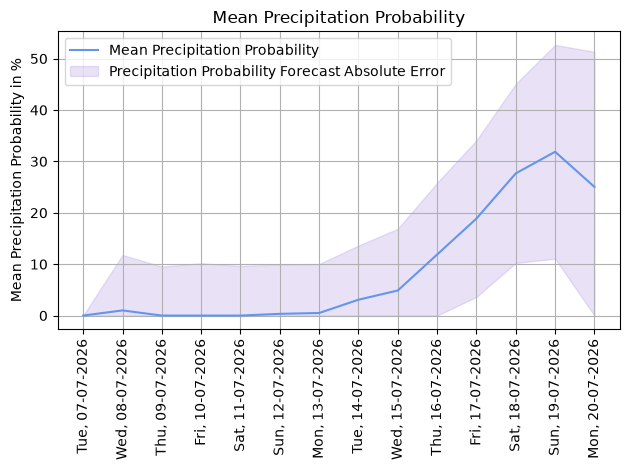

In [2]:
from fue import Forecast, Config
from fue.models import MLUncertaintyModel

model = MLUncertaintyModel().load(run_id="run_20260707_164945_tune")
F = Forecast()
F.fetch_forecast(location_name="aachen")
F.compute_uncertainties(model)
C = Config()
F.plot(C.default_target_columns)